In [1]:
import numpy as np
import qutip as qt
from Quantum_dot_qutip import *
from tqdm import tqdm
import pickle
from entropy import RDM_entropy
import random as rand

N=10
d=2**N

exact_model = Quantum_dot(2)
analog_model = analog_QD(exact_model, h=0.2,J=0.1, theta=0.1, DeltaE=0.5)

def rank_k_haar_state(rank,seed=None):
    #initial qutip state
    state=qt.tensor(qt.rand_ket([2]*2,seed = seed),qt.rand_ket([2]*8,seed = seed))
    for _ in range(rank-1):
    #subsystems with 2 & 8 qubits
        state+=qt.tensor(qt.rand_ket([2]*2,seed = seed),qt.rand_ket([2]*8,seed = seed))
    return state.unit() #normalization

def rank_k_state(rank,seed=None):
    rand.seed(seed)
    result = qt.Qobj(np.zeros((d,1)), dims=[[2]*10, [1]])
    for _ in range(rank):
    #initial qutip state
        state = qt.basis([2]*10)
        #implement a random pauli operator on each qubit
        pauli_ops = [qt.qeye(2), qt.sigmax(), qt.sigmay(), qt.sigmaz()]
        op = qt.tensor([rand.choice(pauli_ops) for _ in range(10)])
        state = op * state
        result += state
    return result.unit() #normalization

def thermal_state(temperature,initial_state):
    H = qt.Qobj(np.zeros((d,d)), dims=[[2]*10, [2]*10])
    for i in range(N-1):
        H += qt.tensor(*[qt.sigmaz() if j in [i,i+1] else qt.qeye(2) for j in range(N)])
    # Calculate the thermal state using the Gibbs distribution
    psi_T = (-H / temperature).expm()*initial_state
    # Normalize the density matrix
    psi_T = psi_T / psi_T.norm()
    return psi_T

def analog_error(initial_state, analog_model : analog_QD,time):
    # Compute the error between the initial state and the analog model
    exact_states=qt.mesolve(analog_model.exact_model.H,initial_state, time).states
    analog_states=qt.mesolve(analog_model.H,initial_state, time).states
    errors = [exact_states[i]-analog_states[i] for i in range(len(time))]
    error_norms = [err.norm('l2') for err in errors]
    return error_norms

seed=123456

entropy_list = []
error_list = []
initial_state = qt.rand_ket([2]*10,seed = 123)
for temperature in tqdm(range(60)):
    state = thermal_state((temperature+10)*0.1,initial_state)
    entropy_list.append(RDM_entropy(state.full(),8)[-1]) #entropy of 8-qubit subsystem
    error_list.append(analog_error(state,analog_model,np.linspace(0, 1.5, 3))[-1])


100%|██████████| 60/60 [00:04<00:00, 13.44it/s]


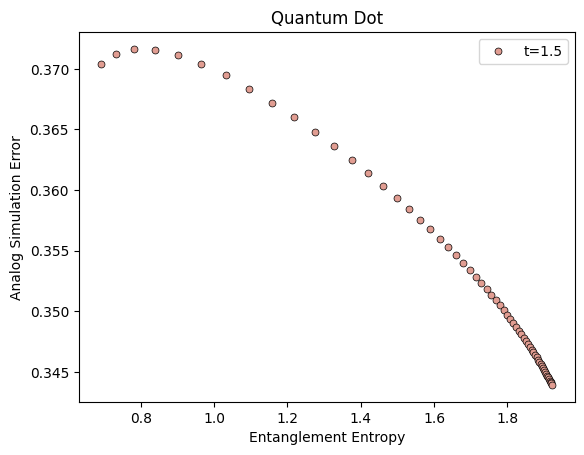

In [2]:
plt.plot(entropy_list,error_list,color='0.3', marker='o', markersize=5, mfc='#e19d92', mec='k', linestyle='', markeredgewidth=0.5,label='t=1.5')
plt.xlabel('Entanglement Entropy')
plt.ylabel('Analog Simulation Error')
plt.title('Quantum Dot')
plt.legend()
plt.show()